In [1]:
import sys
# For notebooks inside research/ftir_hips_chem/:
sys.path.insert(0, './scripts')

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import GroupShuffleSplit

# Config + data
from config import (
    SITES, PROCESSED_SITES_DIR, FILTER_DATA_PATH,
    AERONET_DATA_DIR, WEATHER_DATA_DIR, MAC_VALUE,
    ETHIOPIA_SEASONS, season_for_month,
)

# Exclusions (no new row is silently removed; every cohort rule is exported)
from outliers import (
    EXCLUDED_SAMPLES, MANUAL_OUTLIERS,
    apply_exclusion_flags, apply_threshold_flags,
    get_clean_data, print_exclusion_summary,
)

from data_matching import (
    load_aethalometer_data, load_filter_data,
    match_aeth_filter_data, match_all_parameters,
)
from etad_factors import load_etad_factor_contributions, match_etad_factors

# Plotting—importing applies the repository white-background default.
from plotting import PlotConfig, crossplots, timeseries, distributions, comparisons
from plotting.utils import calculate_regression_stats

from pls_transfer import (
    FTIRTransferPaths, load_current_pls_model, regression_metrics,
    component_cv_curve, select_first_major_minimum,
    ftir_source_band_features, offset_correct,
)

PlotConfig.set(sites='all', layout='individual', show_stats=True, show_1to1=True)
PATHS = FTIRTransferPaths.defaults()
TABLE_DIR = Path('output/tables/pls_calibration_phase2')
PLOT_DIR = Path('output/plots/pls_calibration_phase2')
CAL_DIR = TABLE_DIR / 'calibrations'
for directory in (TABLE_DIR, PLOT_DIR, CAL_DIR):
    directory.mkdir(parents=True, exist_ok=True)

# FTIR EC calibration cohort comparison: deployed, smoke, Ethiopia-shaped, and full-pool analog models

## tl;dr

On the fixed **190-filter Addis cohort** at MAC=10, the deployed SPARTAN values give
intercept **-4.17** and RMSE **1.49 µg m⁻³**. The
meeting-described 906-sample smoke calibration does not fix the intercept
(**-6.91**). Selecting the 300 smoke spectra closest to Addis in CH, carbonyl,
and ~1600 cm⁻¹ feature space moves the intercept toward zero to **-3.69** and
gives RMSE **1.36**, but this remains HIPS/MAC-dependent.

The earlier top-400 analog result (RMSE **0.99**) is not stable after locking a
site-held-out TOR test: the first-major-minimum refit has held-out TOR loading RMSE
**3.27 µg/filter** and Addis RMSE **3.96**. Restricting to
>1500 cm⁻¹ with simple offset correction also performs poorly (Addis RMSE **2.72**),
confirming that offset correction cannot stand in for validated AIRSpec processing.

## Context & Methods

The two meeting conversations define a more specific question than “does the calibration look
better?”: **does a spectrally justified calibration move the FTIR EC intercept toward zero when
HIPS absorption approaches zero, without sacrificing held-out TOR performance?** HIPS EC-equivalent
is therefore on the x-axis and FTIR EC on the y-axis in every external crossplot.

We compare:

1. the deployed SPARTAN FTIR EC values already stored in the unified dataset;
2. the meeting-described 906-sample IMPROVE smoke calibration reconstructed from the June RDS export;
3. a 300-sample smoke calibration chosen only by Addis-like CH, carbonyl, and ~1600 cm⁻¹ spectral features;
4. a full-pool analog calibration with a locked, site-held-out TOR test;
5. a >1500 cm⁻¹ offset-corrected sensitivity model.

### Key Assumptions

- The 906-sample June IMPROVE cohort is the smoke calibration described in the conversations.
- Spectral cohort selection never uses Addis HIPS values or desired regression outcomes.
- The first local CV minimum within one standard error of the global minimum operationalizes the
  instruction to choose the **first major minimum**.
- The >1500 cm⁻¹ model is a sensitivity analysis. Constant offset correction is **not** AIRSpec
  baselining and is not presented as a substitute for EDF 6–8 processing.
- HIPS/MAC comparisons remain diagnostic because no independent Addis TOR EC reference is available.

## Data

### 1. Build the Addis spectrum/HIPS/deployed-EC comparison table

In [2]:
raw_etad = pd.read_csv(PATHS.etad_dir / 'ETAD_FTIR_spectra.csv')
etad_meta = pd.read_csv(PATHS.etad_dir / 'ETAD_metadata.csv')
wcols = sorted([c for c in raw_etad.columns if c not in ('SampleAnalysisId', 'MediaId')],
               key=lambda value: -float(value))
wn = np.array([float(c) for c in wcols])
etad_spectra = raw_etad.groupby('MediaId', as_index=False)[wcols].mean()

hips = pd.read_csv(PATHS.spartan_hips_primary, encoding='cp1252')
hips_etad = (hips[hips['Site'].eq('ETAD')][['FilterId', 'Fabs', 'tau', 'DepositArea', 'Volume']]
             .drop_duplicates('FilterId'))

filter_data = load_filter_data()
deployed = (filter_data[(filter_data['Site'].eq('ETAD')) &
                        (filter_data['Parameter'].eq('EC_ftir'))]
            [['FilterId', 'Concentration', 'CalibrationSetId']]
            .drop_duplicates('FilterId')
            .rename(columns={'Concentration': 'EC_deployed_ugm3'}))

etad = (etad_spectra.merge(etad_meta, on='MediaId', how='left', validate='one_to_one')
        .merge(hips_etad.rename(columns={'FilterId': 'ExternalFilterId'}),
               on='ExternalFilterId', how='left', validate='one_to_one')
        .merge(deployed, left_on='ExternalFilterId', right_on='FilterId',
               how='left', validate='one_to_one'))
etad['SamplingStartDate'] = pd.to_datetime(etad['SamplingStartDate'], errors='coerce')
etad['season'] = etad['SamplingStartDate'].dt.month.map(season_for_month)
etad['has_complete_spectrum'] = etad[wcols].notna().all(axis=1)
etad_eval = etad[etad['has_complete_spectrum'] & etad['Fabs'].notna() &
                 etad['SampleVolume_m3'].gt(0)].copy()
X_etad = etad_eval[wcols].to_numpy(float)
assert np.allclose(wn, np.array([float(c) for c in wcols]))

data_audit = pd.DataFrame([{
    'unique_Addis_spectra': int(etad_spectra['MediaId'].nunique()),
    'Addis_with_newer_HIPS': int(etad_eval['Fabs'].notna().sum()),
    'Addis_with_deployed_EC_and_HIPS': int(etad_eval[['Fabs', 'EC_deployed_ugm3']].dropna().shape[0]),
    'deployed_calibration_sets': ', '.join(sorted(etad_eval['CalibrationSetId'].dropna().astype(str).unique())),
}])
data_audit.to_csv(TABLE_DIR / 'addis_calibration_data_audit.csv', index=False)
display(data_audit)

Filter dataset loaded: 44493 measurements
Sites: ['CHTS' 'ETAD' 'INDH' 'USPA']
Date range: 2013-06-28 to 2024-12-08


,unique_Addis_spectra,Addis_with_newer_HIPS,Addis_with_deployed_EC_and_HIPS,deployed_calibration_sets
0,296,239,190,"11, 17"


### 2. Define an Ethiopia-shaped subset of the smoke calibration using spectra only

In [3]:
smoke = load_current_pls_model(PATHS.ftir_dir, 'EC')
assert np.allclose(smoke.wavenumbers, wn)
smoke_features = ftir_source_band_features(smoke.X, wn)
addis_features = ftir_source_band_features(X_etad, wn)

feature_columns = ['CH_peak', 'carbonyl_peak', 'shoulder_1600_peak']
addis_median = addis_features[feature_columns].median()
addis_iqr = (addis_features[feature_columns].quantile(.75) -
             addis_features[feature_columns].quantile(.25)).clip(lower=1e-6)
smoke_distance = np.sqrt((((smoke_features[feature_columns] - addis_median) /
                           addis_iqr) ** 2).sum(axis=1))

# Very few smoke filters are literally inside all three Addis 5th–95th percentile ranges.
low, high = addis_features[feature_columns].quantile([.05, .95]).to_numpy()
inside_range = ((smoke_features[feature_columns].to_numpy() >= low) &
                (smoke_features[feature_columns].to_numpy() <= high)).all(axis=1)

N_SHAPED_SMOKE = 300
shape_index = np.argsort(smoke_distance.to_numpy())[:N_SHAPED_SMOKE]
smoke_selection = pd.DataFrame({
    'AnalysisId': smoke.analysis_ids,
    'FilterId': smoke.filter_ids,
    'Site': smoke.sites,
    'TOR_EC_loading_ug': smoke.y,
    'Addis_band_feature_distance': smoke_distance,
    'inside_Addis_5_95_range_all_three_features': inside_range,
    'selected_Ethiopia_shaped_smoke': False,
})
smoke_selection.loc[shape_index, 'selected_Ethiopia_shaped_smoke'] = True
smoke_selection = pd.concat([smoke_selection, smoke_features], axis=1)
smoke_selection.to_csv(TABLE_DIR / 'smoke_cohort_spectral_selection.csv', index=False)

smoke_audit = pd.DataFrame([{
    'meeting_described_smoke_calibration_n': len(smoke.y),
    'inside_Addis_5_95_range_n': int(inside_range.sum()),
    'nearest_spectrally_selected_n': len(shape_index),
    'selection_inputs': ', '.join(feature_columns),
    'selection_uses_Addis_HIPS_values': False,
}])
display(smoke_audit)

,meeting_described_smoke_calibration_n,inside_Addis_5_95_range_n,nearest_spectrally_selected_n,selection_inputs,selection_uses_Addis_HIPS_values
0,906,4,300,"CH_peak, carbonyl_peak, shoulder_1600_peak",False


## Results

### 3. Fit the Ethiopia-shaped smoke calibration with the first-major-minimum rule

In [4]:
smoke_shape_curve = component_cv_curve(
    smoke.X[shape_index], smoke.y[shape_index], range(1, 41),
    groups=smoke.sites[shape_index], n_splits=5, random_state=42)
smoke_shape_k, smoke_shape_curve = select_first_major_minimum(smoke_shape_curve)
smoke_shape_curve['model'] = 'Ethiopia-shaped smoke'
smoke_shape_curve.to_csv(TABLE_DIR / 'smoke_shape_component_cv_curve.csv', index=False)
smoke_shape_model = PLSRegression(n_components=smoke_shape_k, scale=False).fit(
    smoke.X[shape_index], smoke.y[shape_index])

etad_eval['EC_smoke_906_ugm3'] = (
    smoke.model.predict(X_etad).ravel() / etad_eval['SampleVolume_m3'].to_numpy())
etad_eval['EC_smoke_shape_300_ugm3'] = (
    smoke_shape_model.predict(X_etad).ravel() / etad_eval['SampleVolume_m3'].to_numpy())

print(f'Original smoke calibration: n={len(smoke.y)}, k={smoke.chosen_n_components}')
print(f'Ethiopia-shaped smoke calibration: n={len(shape_index)}, '
      f'first-major k={smoke_shape_k}, '
      f'global-min k={int(smoke_shape_curve.global_minimum_components.iloc[0])}')

Original smoke calibration: n=906, k=31
Ethiopia-shaped smoke calibration: n=300, first-major k=21, global-min k=21


### 4. Lock a site-held-out TOR test before refitting the full-pool analog calibration

In [5]:
similarity_path = Path('output/tables/pls_transfer/improve_full_pool_addis_similarity.csv')
if not similarity_path.exists():
    raise FileNotFoundError('Run ftir_09_improve_analog_selection.ipynb first.')
similarity = pd.read_csv(similarity_path)

tor = pd.read_csv(
    PATHS.ftir_dir / 'local_db/tables/results_tor.csv',
    usecols=['Site', 'SampleDate', 'Parameter', 'Value', 'AverageFlowRate', 'ElapsedTime'])
tor_ec = tor[tor['Parameter'].eq('EC')].copy()
tor_ec['date'] = pd.to_datetime(tor_ec['SampleDate'], format='mixed', errors='coerce').dt.normalize()
tor_ec = tor_ec.drop_duplicates(['Site', 'date'])
tor_ec['TOR_EC_loading_ug'] = (
    tor_ec['Value'] * (tor_ec['AverageFlowRate'] / 1000 * tor_ec['ElapsedTime']) / 1000)

similarity['date'] = pd.to_datetime(
    similarity['SampleDate'], format='mixed', errors='coerce').dt.normalize()
analog_candidates = (similarity.merge(
    tor_ec[['Site', 'date', 'TOR_EC_loading_ug']], on=['Site', 'date'], how='left',
    validate='many_to_one')
    .query('TOR_EC_loading_ug > 0')
    .sort_values('analog_rank_score')
    .drop_duplicates('FilterId')
    .head(500).copy())

splitter = GroupShuffleSplit(n_splits=1, test_size=.20, random_state=20260717)
train_position, test_position = next(splitter.split(
    analog_candidates, groups=analog_candidates['Site']))
analog_train = analog_candidates.iloc[train_position].copy()
analog_test = analog_candidates.iloc[test_position].copy()
assert set(analog_train['Site']).isdisjoint(set(analog_test['Site']))

needed_ids = set(analog_candidates['AnalysisId'].astype(int))
spectra_parts = []
pool_path = PATHS.ftir_dir / 'local_db/spectra_248_251.csv'
for chunk in pd.read_csv(pool_path, chunksize=750):
    keep = chunk['AnalysisId'].astype(int).isin(needed_ids)
    if keep.any():
        spectra_parts.append(chunk.loc[keep, ['AnalysisId'] + wcols])
analog_spectra = pd.concat(spectra_parts, ignore_index=True).drop_duplicates('AnalysisId')
analog_train = analog_train.merge(analog_spectra, on='AnalysisId', validate='one_to_one')
analog_test = analog_test.merge(analog_spectra, on='AnalysisId', validate='one_to_one')

split_export = pd.concat([
    analog_train[['AnalysisId', 'FilterId', 'Site', 'analog_rank_score']].assign(split='train'),
    analog_test[['AnalysisId', 'FilterId', 'Site', 'analog_rank_score']].assign(split='site-held-out TOR test'),
])
split_export.to_csv(TABLE_DIR / 'locked_analog_train_test_split.csv', index=False)
print(f'Locked analog split: train={len(analog_train)} across {analog_train.Site.nunique()} sites; '
      f'test={len(analog_test)} across {analog_test.Site.nunique()} disjoint sites')

Locked analog split: train=372 across 101 sites; test=128 across 26 disjoint sites


### 5. Fit raw and >1500 cm⁻¹ analog models; retain the global minimum as sensitivity only

In [6]:
upper_mask = wn >= 1500

def fit_variant(label, X_train, X_test, X_addis):
    curve = component_cv_curve(
        X_train, analog_train['TOR_EC_loading_ug'].to_numpy(), range(1, 41),
        groups=analog_train['Site'].to_numpy(), n_splits=5, random_state=42)
    first_k, curve = select_first_major_minimum(curve)
    global_k = int(curve['global_minimum_components'].iloc[0])
    first_model = PLSRegression(n_components=first_k, scale=False).fit(
        X_train, analog_train['TOR_EC_loading_ug'].to_numpy())
    global_model = PLSRegression(n_components=global_k, scale=False).fit(
        X_train, analog_train['TOR_EC_loading_ug'].to_numpy())
    curve['model'] = label
    return {
        'label': label, 'curve': curve, 'first_k': first_k, 'global_k': global_k,
        'first_model': first_model, 'global_model': global_model,
        'test_first': first_model.predict(X_test).ravel(),
        'test_global': global_model.predict(X_test).ravel(),
        'addis_first': first_model.predict(X_addis).ravel(),
        'addis_global': global_model.predict(X_addis).ravel(),
    }

X_analog_train = analog_train[wcols].to_numpy(float)
X_analog_test = analog_test[wcols].to_numpy(float)
raw_variant = fit_variant('Full-spectrum analog', X_analog_train, X_analog_test, X_etad)

X_analog_train_upper = offset_correct(X_analog_train, wn)[:, upper_mask]
X_analog_test_upper = offset_correct(X_analog_test, wn)[:, upper_mask]
X_etad_upper = offset_correct(X_etad, wn)[:, upper_mask]
upper_variant = fit_variant('>1500 cm-1 offset-corrected analog',
                            X_analog_train_upper, X_analog_test_upper, X_etad_upper)

component_curves = pd.concat([raw_variant['curve'], upper_variant['curve']], ignore_index=True)
component_curves.to_csv(TABLE_DIR / 'analog_component_cv_curves.csv', index=False)

volume = etad_eval['SampleVolume_m3'].to_numpy(float)
etad_eval['EC_analog_raw_first_ugm3'] = raw_variant['addis_first'] / volume
etad_eval['EC_analog_raw_global_ugm3'] = raw_variant['addis_global'] / volume
etad_eval['EC_analog_upper_first_ugm3'] = upper_variant['addis_first'] / volume

# Retain the previous top-400/k=36 result only as an explicitly unlocked sensitivity.
prior_path = Path('output/tables/pls_transfer/addis_current_vs_analog_tor_predictions.csv')
if prior_path.exists():
    prior = pd.read_csv(prior_path)[['ExternalFilterId', 'EC_analog_ugm3']].rename(
        columns={'EC_analog_ugm3': 'EC_prior_unlocked_analog_ugm3'})
    etad_eval = etad_eval.merge(prior, on='ExternalFilterId', how='left', validate='one_to_one')
else:
    etad_eval['EC_prior_unlocked_analog_ugm3'] = np.nan

print('Raw analog first/global k:', raw_variant['first_k'], raw_variant['global_k'])
print('Upper-region first/global k:', upper_variant['first_k'], upper_variant['global_k'])

Raw analog first/global k: 10 38
Upper-region first/global k: 7 38


### 6. Audit held-out TOR performance and export candidate calibration coefficients

In [7]:
test_y = analog_test['TOR_EC_loading_ug'].to_numpy(float)
tor_holdout = pd.DataFrame([
    {'model': 'Full-spectrum analog—first major minimum', 'n_components': raw_variant['first_k'],
     **regression_metrics(test_y, raw_variant['test_first'])},
    {'model': 'Full-spectrum analog—global minimum sensitivity', 'n_components': raw_variant['global_k'],
     **regression_metrics(test_y, raw_variant['test_global'])},
    {'model': '>1500 cm-1 offset-corrected—first major minimum', 'n_components': upper_variant['first_k'],
     **regression_metrics(test_y, upper_variant['test_first'])},
])
tor_holdout.to_csv(TABLE_DIR / 'site_held_out_tor_metrics.csv', index=False)

def export_calibration(model, calibration_name, calibration_wn, preprocessing, cohort_n):
    coefficient = (model.x_rotations_ @ model.y_loadings_.T).reshape(-1)
    intercept = float(np.asarray(model._y_mean).reshape(-1)[0] -
                      np.asarray(model._x_mean) @ coefficient)
    table = pd.concat([
        pd.DataFrame({'Wavenumber': [0.0], 'b': [intercept]}),
        pd.DataFrame({'Wavenumber': calibration_wn, 'b': coefficient}),
    ], ignore_index=True)
    path = CAL_DIR / f'{calibration_name}.csv'
    table.to_csv(path, index=False)
    return {
        'calibration': calibration_name, 'cohort_n': cohort_n,
        'n_components': model.n_components, 'target': 'TOR EC loading (ug/filter)',
        'preprocessing': preprocessing, 'coefficient_file': str(path),
    }

manifest = pd.DataFrame([
    export_calibration(smoke_shape_model, 'ec_smoke_shape_300_first_major', wn,
                       'original 2722-point spectrum', len(shape_index)),
    export_calibration(raw_variant['first_model'], 'ec_analog_locked_raw_first_major', wn,
                       'original 2722-point spectrum', len(analog_train)),
    export_calibration(raw_variant['global_model'], 'ec_analog_locked_raw_global_min', wn,
                       'original 2722-point spectrum; sensitivity only', len(analog_train)),
    export_calibration(upper_variant['first_model'], 'ec_analog_locked_upper_first_major', wn[upper_mask],
                       'subtract 3900-4000 cm-1 mean; retain wavenumber >=1500 cm-1; sensitivity only',
                       len(analog_train)),
])
manifest.to_csv(CAL_DIR / 'calibration_manifest.csv', index=False)
display(tor_holdout)
display(manifest)

,model,n_components,n,slope,intercept,R2,RMSE,MAE,bias,median_bias
0,Full-spectrum analog—first major minimum,10,128,0.937269,0.688300,0.601694,3.267386,2.458064,0.185216,0.166812
1,Full-spectrum analog—global minimum sensitivity,38,128,0.822471,0.894354,0.496651,3.648892,2.205944,-0.529389,-0.295834
2,>1500 cm-1 offset-corrected—first major minimum,7,128,0.736504,3.213465,0.323088,4.809320,3.202311,1.100286,0.739101


,calibration,cohort_n,n_components,target,preprocessing,coefficient_file
0,ec_smoke_shape_300_first_major,300,21,TOR EC loading (ug/filter),original 2722-point spectrum,output/tables/pls_calibration_phase2/calibrati...
1,ec_analog_locked_raw_first_major,372,10,TOR EC loading (ug/filter),original 2722-point spectrum,output/tables/pls_calibration_phase2/calibrati...
2,ec_analog_locked_raw_global_min,372,38,TOR EC loading (ug/filter),original 2722-point spectrum; sensitivity only,output/tables/pls_calibration_phase2/calibrati...
3,ec_analog_locked_upper_first_major,372,7,TOR EC loading (ug/filter),subtract 3900-4000 cm-1 mean; retain wavenumbe...,output/tables/pls_calibration_phase2/calibrati...


### 7. Compare every calibration on available pairs and a fixed common Addis cohort

In [8]:
model_columns = {
    'Deployed SPARTAN FTIR EC': 'EC_deployed_ugm3',
    'Smoke IMPROVE (906, k=31)': 'EC_smoke_906_ugm3',
    f'Ethiopia-shaped smoke (300, k={smoke_shape_k})': 'EC_smoke_shape_300_ugm3',
    f'Locked analog raw—first major (k={raw_variant["first_k"]})': 'EC_analog_raw_first_ugm3',
    f'Locked analog raw—global sensitivity (k={raw_variant["global_k"]})': 'EC_analog_raw_global_ugm3',
    f'Locked analog >1500—first major (k={upper_variant["first_k"]})': 'EC_analog_upper_first_ugm3',
    'Prior top-400 analog—unlocked sensitivity': 'EC_prior_unlocked_analog_ugm3',
}
common_mask = etad_eval[list(model_columns.values()) + ['Fabs']].notna().all(axis=1)
print(f'Available HIPS evaluation n={len(etad_eval)}; fixed common cohort n={common_mask.sum()}')

comparison_rows = []
for mac in (6.0, 10.0):
    hips_ec = etad_eval['Fabs'].to_numpy(float) / mac
    for model_name, column in model_columns.items():
        available = etad_eval[column].notna() & etad_eval['Fabs'].notna()
        for cohort_name, mask in [('available pairs', available), ('fixed common cohort', common_mask)]:
            comparison_rows.append({
                'model': model_name, 'cohort': cohort_name, 'MAC_m2_g': mac,
                **regression_metrics(hips_ec[mask], etad_eval.loc[mask, column].to_numpy(float)),
            })
addis_metrics = pd.DataFrame(comparison_rows)
addis_metrics.to_csv(TABLE_DIR / 'addis_calibration_metrics.csv', index=False)
etad_eval[['MediaId', 'ExternalFilterId', 'SamplingStartDate', 'season', 'Fabs'] +
          list(model_columns.values())].to_csv(TABLE_DIR / 'addis_calibration_predictions.csv', index=False)
display(addis_metrics[(addis_metrics['MAC_m2_g'].eq(10)) &
                      (addis_metrics['cohort'].eq('fixed common cohort'))]
        [['model', 'n', 'slope', 'intercept', 'R2', 'RMSE', 'bias']])

Available HIPS evaluation n=239; fixed common cohort n=190


,model,n,slope,intercept,R2,RMSE,bias
15,Deployed SPARTAN FTIR EC,190,1.898281,-4.170345,0.763765,1.486512,0.219531
17,"Smoke IMPROVE (906, k=31)",190,2.654920,-6.905569,0.685474,2.848907,1.181984
19,"Ethiopia-shaped smoke (300, k=21)",190,1.752189,-3.687931,0.741737,1.356156,-0.012002
21,Locked analog raw—first major (k=10),190,2.910623,-6.425865,0.755149,3.958825,2.911304
23,Locked analog raw—global sensitivity (k=38),190,2.520077,-5.038227,0.739766,3.290332,2.390354
25,Locked analog >1500—first major (k=7),190,0.797371,-1.635146,0.613147,2.718475,-2.625386
27,Prior top-400 analog—unlocked sensitivity,190,1.450572,-2.167219,0.759289,0.989942,0.034715


### 8. Separate Addis spectra and calibration behavior by Ethiopian season

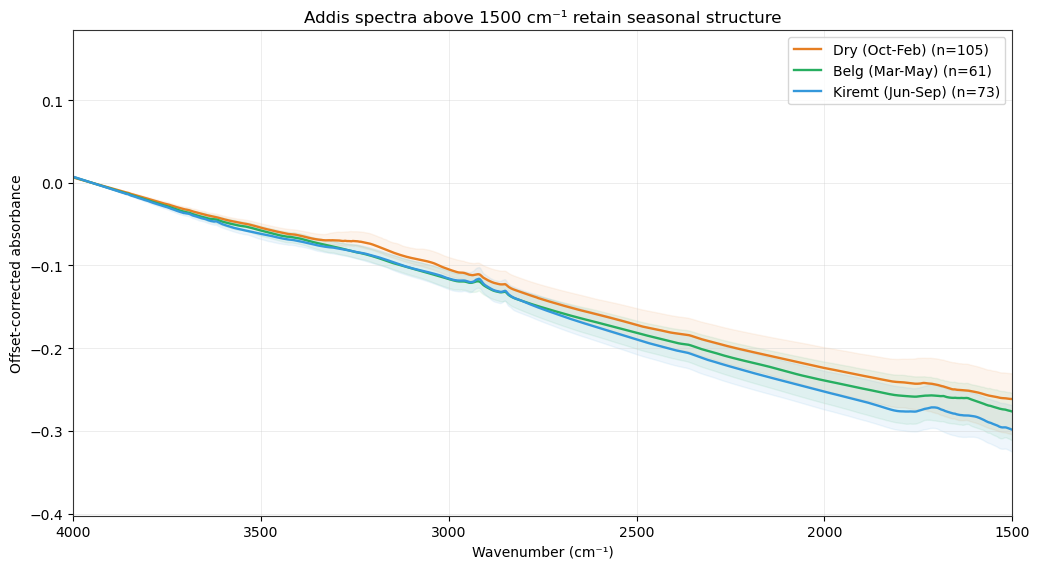

In [9]:
seasonal_rows = []
for season, group in etad_eval.loc[common_mask].groupby('season'):
    hips_ec = group['Fabs'].to_numpy(float) / 10.0
    for model_name, column in model_columns.items():
        seasonal_rows.append({
            'season': season, 'model': model_name, 'MAC_m2_g': 10.0,
            **regression_metrics(hips_ec, group[column].to_numpy(float)),
        })
seasonal_metrics = pd.DataFrame(seasonal_rows)
seasonal_metrics.to_csv(TABLE_DIR / 'addis_calibration_metrics_by_season.csv', index=False)

corrected_etad = offset_correct(X_etad, wn)
fig, ax = plt.subplots(figsize=(10.5, 5.8))
for season, info in ETHIOPIA_SEASONS.items():
    keep = etad_eval['season'].eq(season).to_numpy()
    if keep.any():
        median = np.nanmedian(corrected_etad[keep], axis=0)
        q25, q75 = np.nanpercentile(corrected_etad[keep], [25, 75], axis=0)
        ax.plot(wn, median, color=info['color'], lw=1.7, label=f'{season} (n={keep.sum()})')
        ax.fill_between(wn, q25, q75, color=info['color'], alpha=.08)
ax.set_xlim(4000, 1500)
ax.set(xlabel='Wavenumber (cm⁻¹)', ylabel='Offset-corrected absorbance',
       title='Addis spectra above 1500 cm⁻¹ retain seasonal structure')
ax.legend()
fig.tight_layout()
fig.savefig(PLOT_DIR / 'addis_seasonal_spectra_above_1500.png', dpi=180, bbox_inches='tight')
plt.show()

### 9. Visualize spectral cohort mismatch and component-selection sensitivity

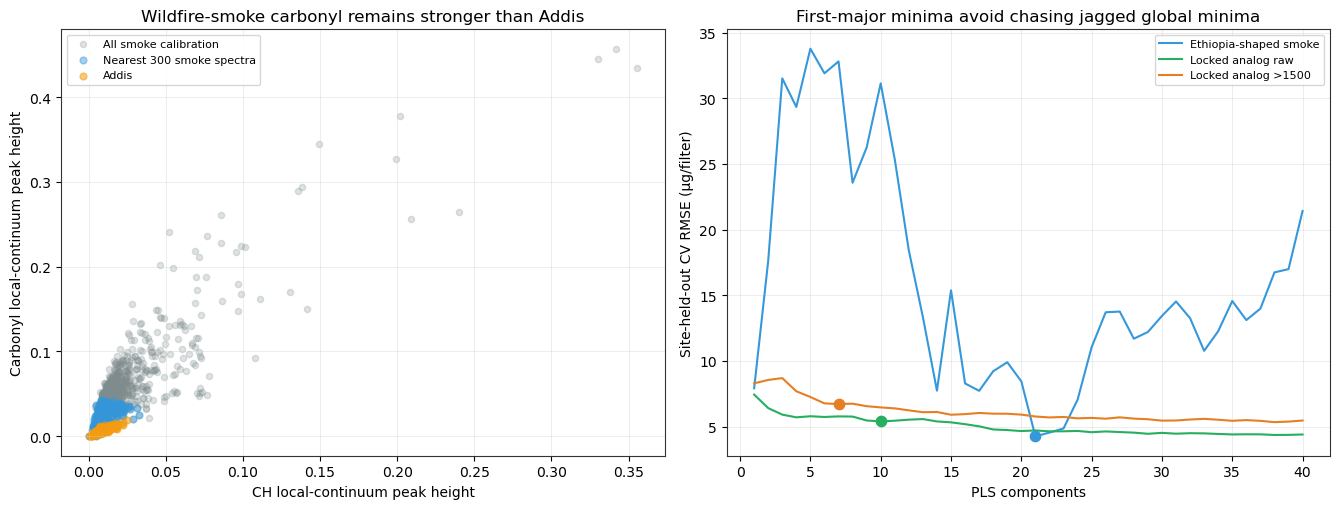

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2))
axes[0].scatter(smoke_features['CH_peak'], smoke_features['carbonyl_peak'],
                s=20, alpha=.25, color='#7F8C8D', label='All smoke calibration')
axes[0].scatter(smoke_features.iloc[shape_index]['CH_peak'],
                smoke_features.iloc[shape_index]['carbonyl_peak'],
                s=24, alpha=.45, color='#3498DB', label='Nearest 300 smoke spectra')
axes[0].scatter(addis_features['CH_peak'], addis_features['carbonyl_peak'],
                s=24, alpha=.55, color=SITES['Addis_Ababa']['color'], label='Addis')
axes[0].set(xlabel='CH local-continuum peak height',
            ylabel='Carbonyl local-continuum peak height',
            title='Wildfire-smoke carbonyl remains stronger than Addis')
axes[0].legend(fontsize=8)

for label, curve, color in [
    ('Ethiopia-shaped smoke', smoke_shape_curve, '#3498DB'),
    ('Locked analog raw', raw_variant['curve'], '#27AE60'),
    ('Locked analog >1500', upper_variant['curve'], '#E67E22'),
]:
    axes[1].plot(curve['n_components'], curve['rmse_mean'], lw=1.5, color=color, label=label)
    selected = curve[curve['selected_first_major_minimum']].iloc[0]
    axes[1].scatter([selected['n_components']], [selected['rmse_mean']], color=color, s=55, zorder=4)
axes[1].set(xlabel='PLS components', ylabel='Site-held-out CV RMSE (µg/filter)',
            title='First-major minima avoid chasing jagged global minima')
axes[1].legend(fontsize=8)
fig.tight_layout()
fig.savefig(PLOT_DIR / 'cohort_and_component_sensitivity.png', dpi=180, bbox_inches='tight')
plt.show()

### 10. Put HIPS on x and FTIR EC on y, with slope and intercept on every panel

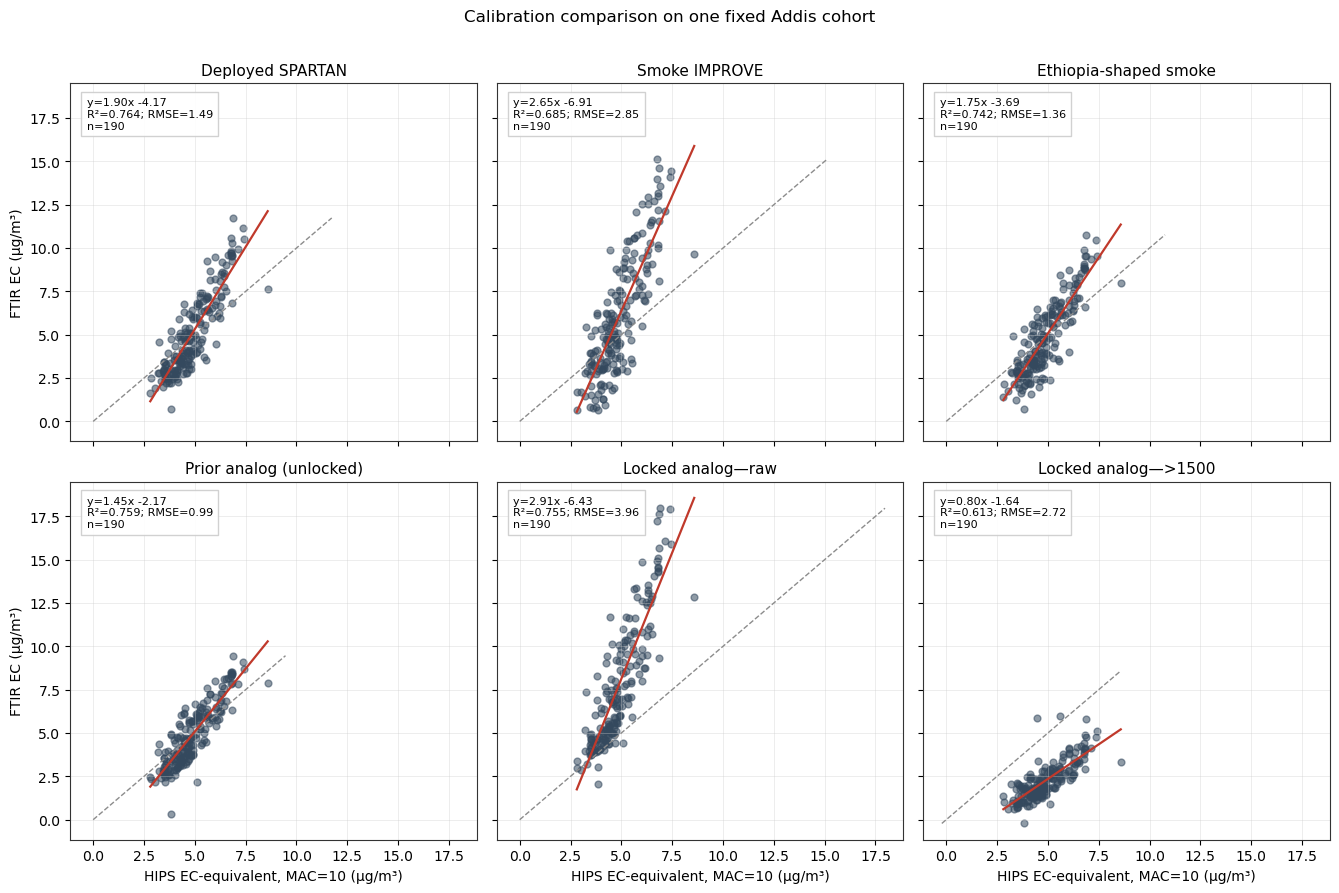

In [11]:
plot_models = [
    ('Deployed SPARTAN', 'EC_deployed_ugm3'),
    ('Smoke IMPROVE', 'EC_smoke_906_ugm3'),
    ('Ethiopia-shaped smoke', 'EC_smoke_shape_300_ugm3'),
    ('Prior analog (unlocked)', 'EC_prior_unlocked_analog_ugm3'),
    ('Locked analog—raw', 'EC_analog_raw_first_ugm3'),
    ('Locked analog—>1500', 'EC_analog_upper_first_ugm3'),
]
common = etad_eval.loc[common_mask].copy()
x = common['Fabs'].to_numpy(float) / 10.0
fig, axes = plt.subplots(2, 3, figsize=(13.5, 8.8), sharex=True, sharey=True)
for ax, (label, column) in zip(axes.flat, plot_models):
    y = common[column].to_numpy(float)
    stats = regression_metrics(x, y)
    ax.scatter(x, y, s=24, alpha=.55, color='#34495E')
    lo, hi = min(0, x.min(), y.min()), max(x.max(), y.max())
    ax.plot([lo, hi], [lo, hi], '--', color='0.55', lw=1)
    fit_x = np.array([x.min(), x.max()])
    ax.plot(fit_x, stats['slope'] * fit_x + stats['intercept'], color='#C0392B', lw=1.6)
    ax.set_title(label, fontsize=11)
    ax.text(.04, .96,
            f'y={stats["slope"]:.2f}x {stats["intercept"]:+.2f}\n'
            f'R²={stats["R2"]:.3f}; RMSE={stats["RMSE"]:.2f}\nn={stats["n"]}',
            transform=ax.transAxes, va='top', fontsize=8,
            bbox=dict(facecolor='white', edgecolor='0.8', alpha=.9))
for ax in axes[-1]:
    ax.set_xlabel('HIPS EC-equivalent, MAC=10 (µg/m³)')
for ax in axes[:, 0]:
    ax.set_ylabel('FTIR EC (µg/m³)')
fig.suptitle('Calibration comparison on one fixed Addis cohort', y=1.01)
fig.tight_layout()
fig.savefig(PLOT_DIR / 'addis_calibration_crossplots_common_cohort.png', dpi=180,
            bbox_inches='tight')
plt.show()

## Takeaways

- **The original smoke-only strategy is not the answer.** Its fixed-cohort intercept is
  -6.91, compared with -4.17 for deployed SPARTAN EC.
- **Spectral selection helps the stated intercept objective.** The Ethiopia-shaped smoke cohort
  reaches -3.69, but only **7** smoke spectra fall inside the Addis 5th–95th
  percentile range for all three source-shape features; the 300-sample cohort is therefore nearest,
  not truly matched.
- **The prior analog improvement is split-sensitive.** The locked, disjoint-site TOR test does not
  reproduce the optimistic top-400 result, so that calibration should not replace the deployed model.
- **The >1500 cm⁻¹ sensitivity is a negative result, not an AIRSpec result.** A complete EDF 6–8
  preprocessing run is still required before concluding that the lower-wavenumber region should be
  excluded.
- **Validation disposition: needs revision before deployment.** The exported coefficient files are
  research candidates for controlled testing; the next decisive data item is an independent Addis
  TOR/EC reference or an agreed MAC/protocol bridge.
